=== Files in Kaggle Input ===
/kaggle/input/datasets/keshavg200/handwrittendigit-mnist/mnist.npz

Keys inside mnist.npz : ['x_test', 'x_train', 'y_train', 'y_test']

Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing  images shape : (10000, 28, 28)
Testing  labels shape : (10000,)

Flattened x_train shape  : (60000, 784)
One-hot label example    : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]  → digit 5


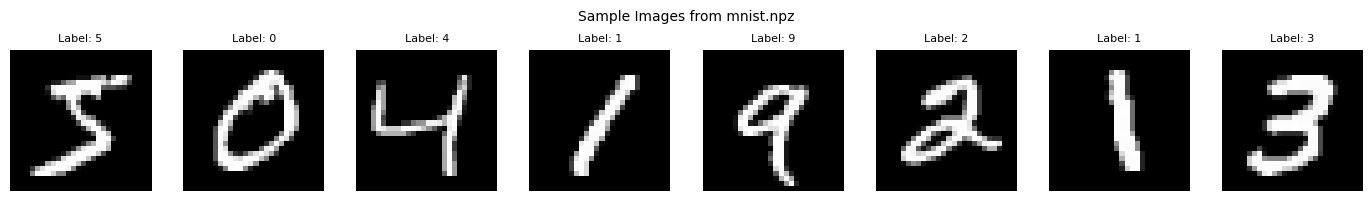

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


── Training Started ──
Epoch 1/11
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7812 - loss: 0.6952 - val_accuracy: 0.9638 - val_loss: 0.1295
Epoch 2/11
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9419 - loss: 0.1928 - val_accuracy: 0.9732 - val_loss: 0.0943
Epoch 3/11
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9561 - loss: 0.1443 - val_accuracy: 0.9755 - val_loss: 0.0821
Epoch 4/11
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9660 - loss: 0.1137 - val_accuracy: 0.9760 - val_loss: 0.0791
Epoch 5/11
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9693 - loss: 0.0991 - val_accuracy: 0.9783 - val_loss: 0.0724
Epoch 6/11
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9721 - loss: 0.0888 - val_accuracy: 0.9787 - val_loss: 0.0785
Epoch 7/11
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9751 - loss: 0.0764 - val_accuracy: 0.9798 - val_loss: 0.0721
Epoch 8/11
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9766 - loss: 0

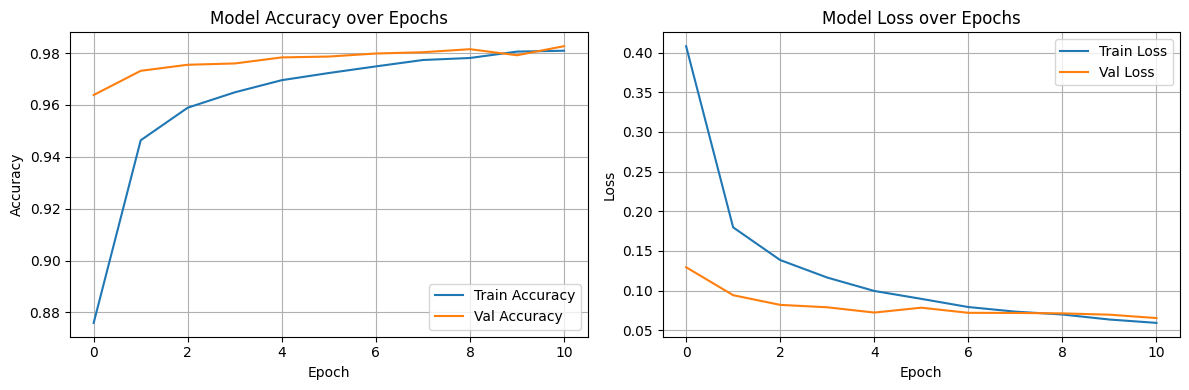

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


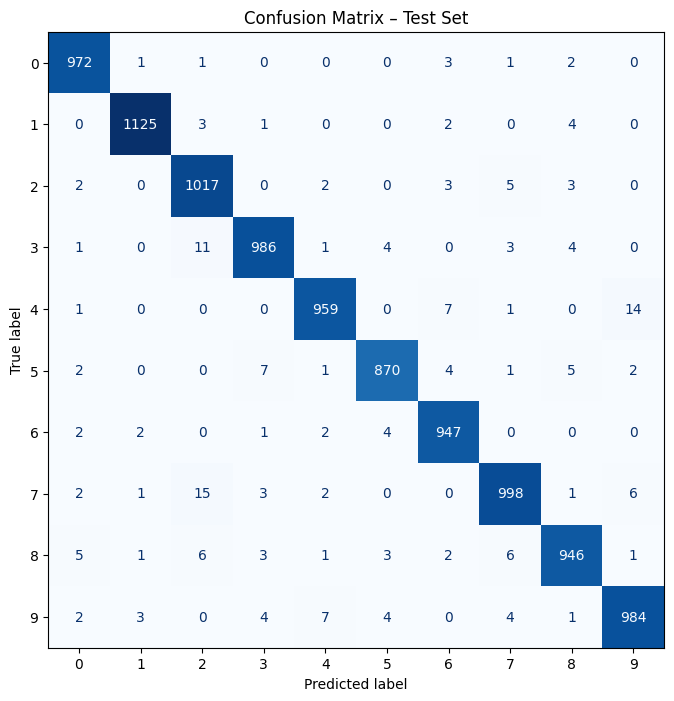


── Sample Predictions ──
  Image 6271 → Predicted: 4 | Actual: 4 | Confidence: 100.0%
  Image 1906 → Predicted: 9 | Actual: 9 | Confidence: 100.0%
  Image 965 → Predicted: 6 | Actual: 6 | Confidence: 64.2%
  Image 1748 → Predicted: 0 | Actual: 0 | Confidence: 96.9%
  Image 2056 → Predicted: 8 | Actual: 8 | Confidence: 97.3%


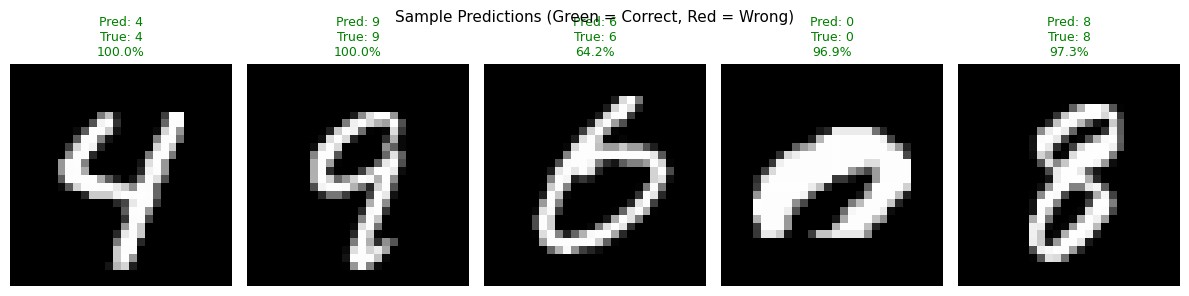


 Model saved → /kaggle/working/mnist_mlp_model.keras

Done! ✓


In [5]:
#Handwritten Digit Recognition using MLP in tensorflow

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os


# First, confirm the file exists at this path
NPZ_PATH = "/kaggle/input/datasets/keshavg200/handwrittendigit-mnist/mnist.npz"

# Print all available files to verify the path
print("=== Files in Kaggle Input ===")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
print("=============================\n")

# Load the .npz file
# .npz is a compressed NumPy file that stores multiple arrays
data = np.load(NPZ_PATH)

# Check what keys (arrays) are stored inside the file
print(f"Keys inside mnist.npz : {list(data.keys())}")
# Expected output: ['x_train', 'y_train', 'x_test', 'y_test']

# Extract training and testing arrays from the .npz file
x_train = data['x_train']    # 60,000 training images  → shape (60000, 28, 28)
y_train = data['y_train']    # 60,000 training labels  → shape (60000,)
x_test  = data['x_test']     # 10,000 testing images   → shape (10000, 28, 28)
y_test  = data['y_test']     # 10,000 testing labels   → shape (10000,)

print(f"\nTraining images shape : {x_train.shape}")
print(f"Training labels shape : {y_train.shape}")
print(f"Testing  images shape : {x_test.shape}")
print(f"Testing  labels shape : {y_test.shape}")

# ============================================================
# STEP 2: Preprocess the Data
# ============================================================

# Step 2a – Images are already 28×28 grayscale 

# Step 2b – Flatten each 28×28 image into a 1D vector of 784 values
#            MLP needs flat input, not a 2D grid
x_train_flat = x_train.reshape(-1, 784)    # (60000, 28, 28) → (60000, 784)
x_test_flat  = x_test.reshape(-1, 784)     # (10000, 28, 28) → (10000, 784)

# Step 2c – Normalize pixel values from [0, 255] → [0.0, 1.0]
#            Smaller values help the network train faster
x_train_norm = x_train_flat.astype("float32") / 255.0
x_test_norm  = x_test_flat.astype("float32")  / 255.0

# Step 2d – One-hot encode labels
#            e.g., digit 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
num_classes  = 10
y_train_ohe  = keras.utils.to_categorical(y_train, num_classes)
y_test_ohe   = keras.utils.to_categorical(y_test,  num_classes)

print(f"\nFlattened x_train shape  : {x_train_norm.shape}")
print(f"One-hot label example    : {y_train_ohe[0]}  → digit {y_train[0]}")

# Visualize a few sample images to confirm data loaded correctly
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train_norm[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Sample Images from mnist.npz", fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3: Define the MLP Architecture
# ============================================================
# Input  Layer : 784 neurons (one per pixel)
# Hidden Layer1: 128 neurons + ReLU activation
# Hidden Layer2:  64 neurons + ReLU activation
# Output Layer :  10 neurons + Softmax (probability per digit)

model = keras.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(128, activation='relu'),   # Hidden Layer 1
    layers.Dropout(0.2),                    # Prevents overfitting

    layers.Dense(64, activation='relu'),    # Hidden Layer 2
    layers.Dropout(0.2),

    layers.Dense(num_classes, activation='softmax')  # Output Layer
])

model.summary()   # Shows layer shapes and total parameters

# ============================================================
# STEP 4–8: Compile the Model
# (Handles weight init, forward pass, loss, backprop & update)
# ============================================================

model.compile(
    optimizer = 'adam',                    # Adaptive gradient descent (Step 8)
    loss      = 'categorical_crossentropy',# Measures prediction error (Step 6)
    metrics   = ['accuracy']
)

# ============================================================
# STEP 9: Train the Model
# ============================================================

print("\n── Training Started ──")
history = model.fit(
    x_train_norm, y_train_ohe,
    epochs           = 11,     # Full passes over the training data
    batch_size       = 64,     # Images processed per gradient update
    validation_split = 0.1,    # 10% of training data used for validation
    verbose          = 1
)
print("── Training Complete ──\n")

# ============================================================
# STEP 10: Evaluate the Model
# ============================================================

test_loss, test_accuracy = model.evaluate(x_test_norm, y_test_ohe, verbose=0)
print(f" Test Accuracy : {test_accuracy * 100:.2f}%")
print(f" Test Loss     : {test_loss:.4f}")

# Plot Training vs Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix — shows which digits get confused with each other
y_pred = np.argmax(model.predict(x_test_norm), axis=1)
cm     = confusion_matrix(y_test, y_pred)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix – Test Set')
plt.show()

# ============================================================
# STEP 11: Predict New Handwritten Digits
# ============================================================

print("\n── Sample Predictions ──")
sample_indices = np.random.choice(len(x_test_norm), 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, idx in enumerate(sample_indices):

    # Preprocess: reshape to (1, 784) for model input
    sample       = x_test_norm[idx].reshape(1, 784)

    # Forward pass through trained model
    pred_probs   = model.predict(sample, verbose=0)

    # Pick the class with highest probability
    pred_digit   = np.argmax(pred_probs)
    actual_digit = y_test[idx]
    confidence   = np.max(pred_probs) * 100

    axes[i].imshow(x_test_norm[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(
        f"Pred: {pred_digit}\nTrue: {actual_digit}\n{confidence:.1f}%",
        fontsize=9,
        color='green' if pred_digit == actual_digit else 'red'
    )
    axes[i].axis('off')
    print(f"  Image {idx} → Predicted: {pred_digit} | Actual: {actual_digit} | Confidence: {confidence:.1f}%")

plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=11)
plt.tight_layout()
plt.show()

# Save trained model to Kaggle output folder
model.save('/kaggle/working/mnist_mlp_model.keras')
print("\n Model saved → /kaggle/working/mnist_mlp_model.keras")
print("\nDone! ✓")
